In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pickle
import time
import seaborn as sns
from scipy.optimize import fmin, minimize, LinearConstraint, Bounds
from efficient_fpt.multi_stage_cy import compute_loss_parallel, print_num_threads
import pymc as pm
import pytensor 
import pytensor.tensor as pt 
from pytensor.graph import Apply, Op


data = pickle.load(open("addm_data_20251015-163921.pkl", "rb"))


In [2]:
DATA_TYPE = np.float64

a = data["a"] # decision threshold  
b = data["b"] # slope of collapsing boundary 
x0 = data["x0"] # initial starting point? 
eta_true = data["eta"] # scaling factor against the option not being fixated 
kappa_true = data["kappa"] # parametrizes whole drift..? 
r1_data = data["r1_data"] # reward value of option 1 
r2_data = data["r2_data"] # reward value of option 2 
flag_data = data["flag_data"].astype(np.int32) # what is this 

sigma = data["sigma"] # diffusion noise 
T = data["T"] # max time 

mu1_true_data = kappa_true * (r1_data - eta_true * r2_data)
mu2_true_data = kappa_true * (eta_true * r1_data - r2_data)

mu_true_data = data["mu_array_padded_data"].astype(DATA_TYPE)
sacc_data = data["sacc_array_padded_data"].astype(DATA_TYPE) # what is the sacc_data? 
length_data = data["d_data"].astype(np.int32)
rt_data = data["decision_data"][:, 0].astype(DATA_TYPE)
choice_data = data["decision_data"][:, 1].astype(np.int32)

num_data, max_d = mu_true_data.shape
print(num_data, max_d)

50000 12


In [3]:
print(sacc_data[210])

[0.         0.96606344 1.45508996 0.         0.         0.
 0.         0.         0.         0.         0.         0.        ]


In [10]:
print(rt_data)

[3.508225 1.070135 2.813685 ... 0.554615 1.290325 1.698795]


In [3]:
num_iter = 5
start_time = time.time()
for _ in range(num_iter):
    loss = compute_loss_parallel(
        mu1_true_data,
        mu2_true_data,
        rt_data,
        choice_data,
        flag_data,
        sacc_data,
        length_data,
        max_d,
        sigma,
        a,
        b,
        x0,
        num_threads=32,
    )
    print(loss)
end_time = time.time()
print(f"Likelihood evaluation time: {(end_time - start_time) / num_iter:.3f} s")

1.4853344770222026
1.4853344770222021
1.4853344770222021
1.4853344770222023
1.4853344770222021
Likelihood evaluation time: 1.076 s


50000


(array([3.52768527e-04, 8.81921319e-04, 1.05830558e-03, 2.46937969e-03,
        2.46937969e-03, 4.76237512e-03, 5.29152791e-03, 5.46791217e-03,
        6.70260202e-03, 1.14649771e-02, 1.44635096e-02, 1.76384264e-02,
        1.79911949e-02, 2.01078061e-02, 2.89270192e-02, 2.76923294e-02,
        3.26310888e-02, 3.63351583e-02, 3.80990010e-02, 4.53307558e-02,
        5.43263532e-02, 6.04998025e-02, 6.22636451e-02, 6.80843258e-02,
        7.40813908e-02, 8.34297567e-02, 8.78393633e-02, 9.48947339e-02,
        1.09534628e-01, 1.21175989e-01, 1.29995202e-01, 1.39343568e-01,
        1.54159846e-01, 1.68799740e-01, 1.76913416e-01, 1.95962917e-01,
        2.06722357e-01, 2.31768923e-01, 2.35825761e-01, 2.56639104e-01,
        2.76041373e-01, 2.84860586e-01, 2.87859118e-01, 2.82567590e-01,
        2.50465654e-01, 1.67035898e-01, 7.72563075e-02, 1.21705142e-02,
        1.76384264e-04, 0.00000000e+00, 0.00000000e+00, 5.29152791e-04,
        2.06369589e-02, 7.02009370e-02, 1.25409211e-01, 1.672122

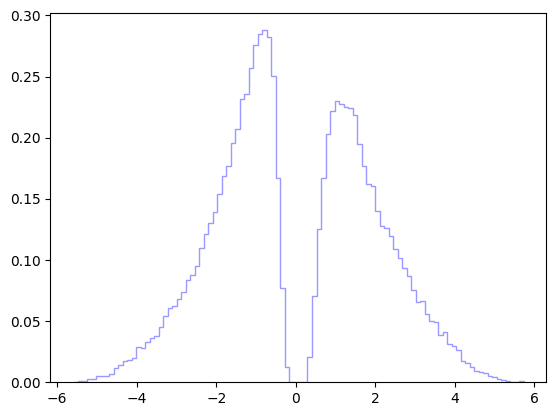

In [4]:
print(len(rt_data))
plt.hist(rt_data*choice_data, bins=100,
    histtype="step",
    color="blue",
    density=True,
    alpha=0.4,)

In [6]:
T = 2.1 / 0.3 
rng = np.random.default_rng() 
fixations = rng.gamma(6, 0.1, size=1000)
sacc_array = np.insert(np.cumsum(fixations), 0, 0)
sacc_array = sacc_array[sacc_array < T]
print(sacc_array.shape)

(13,)


In [4]:
# Wrap blackbox likelihood function as a pytensor Op

from pytensor.graph import Apply, Op 

class ADDMLik(Op):         
    def make_node(self, mu1, mu2, rt, choice, flag, sacc, length, max_d, sigma, a, b, x0): 
        mu1 = pt.as_tensor_variable(mu1) 
        mu2 = pt.as_tensor_variable(mu2) 
        rt = pt.as_tensor_variable(rt) 
        choice = pt.as_tensor_variable(choice) 
        max_d = pt.as_tensor_variable(max_d)
        sigma = pt.as_tensor_variable(sigma)
        a = pt.as_tensor_variable(a)
        b = pt.as_tensor_variable(b)
        x0 = pt.as_tensor_variable(x0)
        flag = pt.as_tensor_variable(flag) 
        sacc = pt.as_tensor_variable(sacc) 
        length = pt.as_tensor_variable(length) 
        outputs = [pt.vector(dtype=DATA_TYPE)] 
        return Apply(self, [mu1, mu2, rt, choice, max_d, sigma, a, b, x0, flag, sacc, length], outputs)
    
    def perform(self, node, inputs, outputs): 
        mu1, mu2, rt, choice, max_d, sigma, a, b, x0, flag, sacc, length = inputs 
        output = compute_loss_parallel(
            mu1,
            mu2,
            rt,
            choice,
            flag,
            sacc,
            length,
            max_d,
            sigma,
            a,
            b,
            x0,
            num_threads=32,
        ) 
        outputs[0][0] = np.array(output, dtype=DATA_TYPE)

In [5]:
loglike_op = ADDMLik()
test_loglike = loglike_op(mu1_true_data, mu2_true_data, rt_data, choice_data, flag_data, sacc_data, length_data, max_d, sigma, a, b, x0,)

In [6]:
pytensor.dprint(test_loglike, print_type=True)

ADDMLik [id A] <Vector(float64, shape=(?,))>
 ├─ [ 0.95  0. ... .15 -0.55] [id B] <Vector(float64, shape=(50000,))>
 ├─ [-0.1  -0. ... .55 -1.15] [id C] <Vector(float64, shape=(50000,))>
 ├─ [3.508225 ... 1.698795] [id D] <Vector(float64, shape=(50000,))>
 ├─ [ 1 -1  1 ... 1  1 -1] [id E] <Vector(int32, shape=(50000,))>
 ├─ 12 [id F] <Scalar(int8, shape=())>
 ├─ 1 [id G] <Scalar(int8, shape=())>
 ├─ 2.1 [id H] <Scalar(float64, shape=())>
 ├─ 0.3 [id I] <Scalar(float64, shape=())>
 ├─ -0.2 [id J] <Scalar(float64, shape=())>
 ├─ [0 0 1 ... 1 1 1] [id K] <Vector(int32, shape=(50000,))>
 ├─ [[0. ... ]] [id L] <Matrix(float64, shape=(50000, 12))>
 └─ [7 3 4 ... 2 3 3] [id M] <Vector(int32, shape=(50000,))>


In [7]:
test_loglike.eval()

<<!! BUG IN FGRAPH.REPLACE OR A LISTENER !!>> <class 'TypeError'> Cannot convert Type Scalar(float64, shape=()) (of Variable 1.4853344770222023) into Type Vector(float64, shape=(?,)). You can try to manually convert 1.4853344770222023 into a Vector(float64, shape=(?,)). constant_folding
ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: constant_folding
ERROR (pytensor.graph.rewriting.basic): node: ADDMLik([ 0.95  0. ... .15 -0.55], [-0.1  -0. ... .55 -1.15], [3.508225 ... 1.698795], [ 1 -1  1 ... 1  1 -1], 12, 1, 2.1, 0.3, -0.2, [0 0 1 ... 1 1 1], [[0. ... ]], [7 3 4 ... 2 3 3])
ERROR (pytensor.graph.rewriting.basic): TRACEBACK:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/oscar/data/frankmj/azhang/efficient-fpt/.venv/lib/python3.11/site-packages/pytensor/graph/rewriting/basic.py", line 1968, in process_node
    fgraph.replace_all_validate_remove(  # type: ignore
  File "/oscar/data/frankmj/azhang/efficient-fpt/.venv/lib/python3.11/s

array(1.48533448)

In [9]:
def custom_dist_addm_lik(mu1, mu2, rt, choice, flag, sacc, length, max_d, sigma, a, b, x0):
    loglik = loglike_op(mu1, mu2, rt, choice, flag, sacc, length, max_d, sigma, a, b, x0)
    return loglik

In [10]:
# define pymc model 

with pm.Model() as model: 
    rt = pm.Data("rt", rt_data)
    choice = pm.Data("choice", choice_data)
    flag = pm.Data("flag", flag_data)
    sacc = pm.Data("sacc", sacc_data)
    length = pm.Data("length", length_data)
    r1 = pm.Data("r1", r1_data)
    r2 = pm.Data("r2", r2_data)

    eta = pm.Beta("eta", alpha=2, beta=2)
    kappa = pm.Gamma("kappa", mu=2, sigma=1/4.0)
    a = pm.Gamma("a", mu=2.0, sigma=0.5)
    b = pm.Beta("b", alpha=2, beta=2)
    x0 = pm.Beta("x0", alpha=2, beta=2)
    
    mu1 = pm.Deterministic("mu1", kappa * (r1 - eta * r2))
    mu2 = pm.Deterministic("mu2", kappa * (eta * r1 - r2))

    # define likelihood 
    obs = pm.CustomDist("likelihood", 
                        mu1=mu1, 
                        mu2=mu2, 
                        rt=rt, 
                        choice=choice, 
                        flag=flag, 
                        sacc=sacc, 
                        length=length,
                        max_d=max_d,
                        sigma=sigma,
                        a=a,
                        b=b,
                        x0=x0,
                        logp=custom_dist_addm_lik,
                        observed=np.zeros(len(rt_data), dtype=DATA_TYPE),
                       )




TypeError: RandomVariable.make_node() got an unexpected keyword argument 'mu1'